# Exercise 7.1
### Classification of magnetic phases using fully-connected networks

Imagine a 2-dimensional lattice arrangement of $n \times n$ magnetic dipole moments (spins) that can be in one of two states ($+1$ or $−1$, Ising model).
With interactions between spins being short ranged, each spin interacts only with its four neighbors.
The probability to find a spin in one of the orientations is a function of temperature $T$ according to $p \sim e^{−a/T},\;a = \mathrm{const.}$).

At extremely low temperatures $T \rightarrow 0$, neighboring spins have a very low probability of different orientations, so that a uniform overall state (ferromagnetic state) is adopted, characterized by $+1$ or $−1$.
At very high temperatures $T \rightarrow \infty$, a paramagnetic phase with random spin alignment results, yielding $50\%$ of $+1$ and $0%$ of $−1$ orientations.
Below a critical temperature $0 < T < T_c$, stable ferromagnetic domains emerge, with both orientations being equally probable in the absence of an external magnetic field.
The spin-spin correlation function diverges at $T_c$, whereas the correlation decays for $T > T_c$.

The data for this task contain the $n \times n$ dipole orientations on the lattice for different temperatures $T$.
Classify the two magnetic phases (paramagnetic/ferromagnetic)!

In [2]:
from tensorflow import keras
import numpy as np
callbacks = keras.callbacks
layers = keras.layers

from keras.models import Sequential
from keras.layers import Dense, Flatten

### Load and prepare dataset
See https://doi.org/10.1038/nphys4035 for more information

In [3]:
import gdown
url = "https://drive.google.com/u/0/uc?export=download&confirm=HgGH&id=1Ihxt1hb3Kyv0IrjHlsYb9x9QY7l7n2Sl"
output = 'ising_data.npz'
#gdown.download(url, output, quiet=True)
#path='/Users/ludovicapirelli/Desktop/ML/hi_ml'
f = np.load(output, allow_pickle=True)
n_train = 20000

x_train, x_test = f["C"][:n_train], f["C"][n_train:]
T_train, T_test = f["T"][:n_train], f["T"][n_train:]

In [1]:
import matplotlib.pyplot as plt

for i,j in enumerate(np.random.choice(n_train, 6)):
    plt.subplot(2,3,i+1)
    image = x_train[j]
    plot = plt.imshow(image)
    plt.title("T: %.2f" % T_train[j])

plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

Text(0, 0.5, 'frequency')

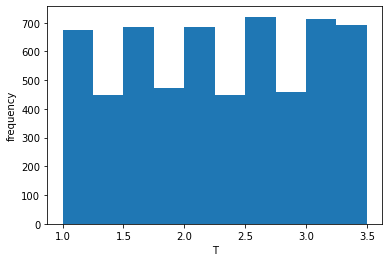

In [5]:
plt.hist(T_test)
plt.xlabel("T")
plt.ylabel("frequency")

#### Set up training data - define magnetic phases

In [6]:
Tc = 2.27
y_train, y_test = T_train > Tc, T_test > Tc

 ### Task

 - evaluate the test accuracy for a fully-connected network,
 - plot the test accuracy vs. temperature.


In [7]:
#start homework
print("shapes: T_train, T_test: "+str(T_train.shape)+str(T_test.shape))
print("shapes: x_train, x_test: "+str(x_train.shape)+str(x_test.shape))
print("shapes: y_train, y_test: "+str(y_train.shape)+str(y_test.shape))
print("A look at the data")
print("T for train: "+str(T_train[0:8]))
print("y for train (are T > Tc?): "+str(y_train[0:8]))

shapes: T_train, T_test: (20000,)(6000,)
shapes: x_train, x_test: (20000, 32, 32)(6000, 32, 32)
shapes: y_train, y_test: (20000,)(6000,)
A look at the data
T for train: [3.1 1.8 1.  3.  2.  2.8 3.  1.2]
y for train (are T > Tc?): [ True False False  True False  True  True False]


In [8]:
#we want to use categorical cross entropy: data have to be one-hot encoded
#for the moment, y=[0,1] -> we want 0 <-> [1,0], 1 <-> [0,1]
#we could do that with an analogous function as in Exercise 4.3 but we use keras functions

y_train_one_hot = keras.utils.to_categorical(y_train, num_classes = 2)
print(y_train_one_hot)

y_test_one_hot = keras.utils.to_categorical(y_test, num_classes = 2)
#x have to be squeezed in one dim! add a flatten layer


[[0. 1.]
 [1. 0.]
 [1. 0.]
 ...
 [1. 0.]
 [0. 1.]
 [0. 1.]]


In [29]:
#build the net
imag_side=32
n_input=imag_side*imag_side #image size
n_nodes=imag_side

model = Sequential()

#first layer
model.add(layers.InputLayer(input_shape=(32, 32, 1)))
model.add(layers.Reshape((1024,)))
model.add(Dense(n_nodes,activation='relu'))
#alternative
#model.add(Flatten(input_shape=(imag_side,imag_side))) 
#model.add(Dense(n_nodes, input_dim=n_input, activation='relu')) 

model.add(layers.Dropout(0.3)) #regularization. without it, the loss fluctuates more

model.add(Dense(n_nodes,activation='relu'))
model.add(layers.Dropout(0.3))

model.add(Dense(2, activation='softmax'))

# Set loss function and optimiser algorithm
optim=keras.optimizers.Adam(learning_rate=0.0005)
loss_model=keras.losses.CategoricalCrossentropy()
#other possibility (from solution: do not use one-hot encoding, use then binary crossentropy. activation function is sigmoid instead of softmax)
model.compile(loss=loss_model,optimizer=optim,metrics=['accuracy'])

model.build((None, 1))
print (model.summary())

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_6 (Reshape)         (None, 1024)              0         
                                                                 
 dense_26 (Dense)            (None, 32)                32800     
                                                                 
 dropout_15 (Dropout)        (None, 32)                0         
                                                                 
 dense_27 (Dense)            (None, 32)                1056      
                                                                 
 dropout_16 (Dropout)        (None, 32)                0         
                                                                 
 dense_28 (Dense)            (None, 2)                 66        
                                                                 
Total params: 33,922
Trainable params: 33,922
Non-trai

In [30]:
epochs =  30
save_period = 6  # after how many epochs the model should be saved?
batch_dim=64

history = model.fit(x_train, y_train_one_hot, 
                    validation_data=(x_test, y_test_one_hot),
                    epochs=epochs, batch_size=batch_dim)

#saving checkpoints
"""
chkpnt_saver = keras.callbacks.ModelCheckpoint("weights-{epoch:02d}.hdf5", save_weights_only=True, save_freq=save_period)

results = model.fit(
    x_train,
    y_train_one_hot,
    batch_size=batch_dim,
    epochs=epochs,
    verbose=1,
    callbacks=[chkpnt_saver]
    )
"""

Epoch 1/30
313/313 [==============================] - 10s 26ms/step - loss: 21.9934 - accuracy: 0.5034 - val_loss: 14.3698 - val_accuracy: 0.4938
Epoch 2/30
313/313 [==============================] - 8s 25ms/step - loss: 52.0138 - accuracy: 0.5083 - val_loss: 4.0008 - val_accuracy: 0.5140
Epoch 3/30
313/313 [==============================] - 8s 26ms/step - loss: 27.1332 - accuracy: 0.5040 - val_loss: 10.8590 - val_accuracy: 0.5212
Epoch 4/30
313/313 [==============================] - 8s 26ms/step - loss: 14.2960 - accuracy: 0.4980 - val_loss: 5.0468 - val_accuracy: 0.5175
Epoch 5/30
313/313 [==============================] - 8s 26ms/step - loss: 10.9659 - accuracy: 0.5003 - val_loss: 0.9727 - val_accuracy: 0.5128
Epoch 6/30
313/313 [==============================] - 8s 26ms/step - loss: 8.6558 - accuracy: 0.4997 - val_loss: 1.0019 - val_accuracy: 0.4985
Epoch 7/30
313/313 [==============================] - 8s 26ms/step - loss: 6.5583 - accuracy: 0.5008 - val_loss: 1.7866 - val_accuracy

'\nchkpnt_saver = keras.callbacks.ModelCheckpoint("weights-{epoch:02d}.hdf5", save_weights_only=True, save_freq=save_period)\n\nresults = model.fit(\n    x_train,\n    y_train_one_hot,\n    batch_size=batch_dim,\n    epochs=epochs,\n    verbose=1,\n    callbacks=[chkpnt_saver]\n    )\n'

In [31]:
# The history object returned by the model training above 
# contains the values of the loss function (the mean-squared-error)
# at different epochs
# We discard the first epoch as the loss value is very high,
# obscuring the rest of the distribution
train_loss = history.history["loss"][1:]
test_loss = history.history["val_loss"][1:]
acc=history.history["accuracy"]
val_acc=history.history['val_accuracy']

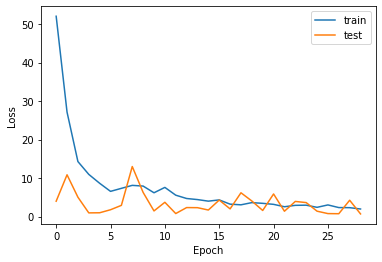

In [32]:
# Prepare and plot loss over time
plt.plot(train_loss,label="train")
plt.plot(test_loss,label="test")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

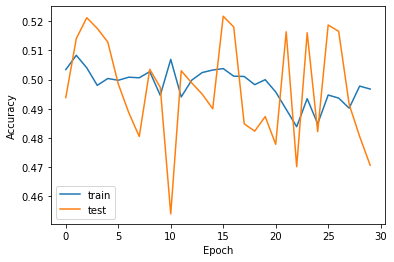

In [33]:
#plot accuracy over time

plt.plot(acc,label="train")
plt.plot(val_acc,label="test")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [72]:
#evaluate the model on the test set
results = model.evaluate(x_test, y_test_one_hot, batch_size=batch_dim, verbose=1)
loss_res=results[0]
acc_res=results[1]
print(acc_res)

#let's see what the model predicts for different data (so that we have array of accuracies, not only mean value)
preds = model.predict(x_test).round().squeeze()
acc_check=[]
for i in range(len(preds)):
    acc_check.append(preds[i].tolist()==y_test_one_hot[i].tolist())
acc_array=np.array(acc_check).astype(float)

#acc_array = (preds == y_test_one_hot).astype(float) #from sol
#here it does not work because our results are one-hot encod, so our y are of format [..,...] instead of being a value
acc_mean=np.mean(acc_array)
print(acc_mean)



94/94 [==============================] - 2s 16ms/step - loss: 0.7040 - accuracy: 0.4707
0.47066667675971985
188/188 [==============================] - 1s 3ms/step
0.4706666666666667


(6000,)

array([1., 0., 0., ..., 1., 1., 0.])

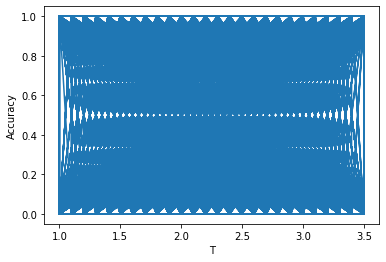

In [77]:
#plot accuracy over T

plt.plot(T_test,acc_array,label="")
plt.xlabel("T")
plt.ylabel("Accuracy")
plt.show()

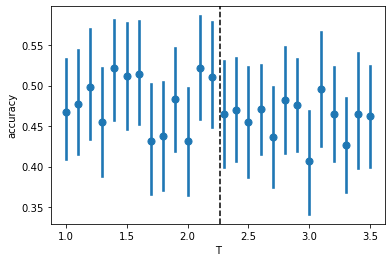

In [75]:
import seaborn as sns


ax = sns.regplot(x=T_test, y=acc_array, x_estimator= np.mean, fit_reg=False)
ax.set_ylabel("accuracy")
ax.set_xlabel("T")
plt.axvline(x=Tc, color='k', linestyle='--', label='Tc')